# 01 — Tyre Degradation: Exploratory Data Analysis
## pitwall · Claudia Maria Lopez Bombin

This notebook explores the raw lap time data from FastF1 to understand
how tyre degradation manifests in the data. Before fitting any model,
we need to answer three questions:

  1. **Is the signal there?** Can we actually see degradation in lap times,
     or is it drowned out by noise (traffic, track evolution, weather)?

  2. **What shape is it?** Is it linear? Exponential? Does the "cliff"
     actually exist as a discontinuity, or is it a smooth acceleration?

  3. **How does it vary?** Across compounds, circuits, temperatures.
     A model fitted on Silverstone data should not be applied blindly to Monaco.

### What we expect to find (and what makes this interesting)

Pirelli's compounds are designed with explicit degradation targets:
- Soft: high initial grip, cliff around lap 18-22
- Medium: balanced, cliff around lap 28-34
- Hard: durable, rarely reaches cliff in a single stint

The cliff is not a manufacturing defect — it is physics. As the tyre
surface wears, the underlying construction starts to flex differently,
generating heat in a positive feedback loop. Above a threshold temperature,
the rubber compound literally begins to grain or blister, losing grip
dramatically. The Weibull model captures this: shape parameter k > 1
means increasing hazard rate (accelerating degradation), and the inflection
point of the Weibull CDF is exactly the cliff lap.

### Data provenance
`data/processed/laps_clean.parquet` was generated by `fetch_data.py`.
Only green-flag, clean-air laps are included (gap ahead > 2s).
Lap time delta is computed relative to each driver's new-tyre baseline
(median of first 3 laps on that set).

# Setup

In [12]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.optimize import curve_fit
from scipy.stats import pearsonr
from pathlib import Path

# Pitwall modules
import sys
PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "core").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT))
from core.tyre_model import WeibullTyreModel, CLIFF_LAP_MEDIAN, MAX_DEGRADATION
from core.mdp import Compound

# ── Plot style ──
plt.rcParams.update({
    "figure.facecolor":  "#0d0d0d",
    "axes.facecolor":    "#111111",
    "axes.edgecolor":    "#2a2a2a",
    "axes.labelcolor":   "#888",
    "axes.titlecolor":   "#e8e8e2",
    "xtick.color":       "#555",
    "ytick.color":       "#555",
    "text.color":        "#e8e8e2",
    "grid.color":        "#1a1a1a",
    "grid.linestyle":    "--",
    "grid.alpha":        1.0,
    "font.family":       "monospace",
    "figure.dpi":        120,
    "axes.spines.top":   False,
    "axes.spines.right": False,
})

COMPOUND_COLORS = {
    "SOFT":   "#e8220a",
    "MEDIUM": "#f5c400",
    "HARD":   "#cccccc",
    "INTER":  "#4a9eff",
    "WET":    "#4a9eff",
}

print("Setup complete.")

Setup complete.


# 1. Load and inspect the data

In [13]:
data_path = Path("../data/processed/laps_clean.parquet")
df = pd.read_parquet(data_path)

# Normalize tyre age column name across datasets
if "TyreAge" not in df.columns and "TyreLife" in df.columns:
    df["TyreAge"] = df["TyreLife"]

print(f"Shape: {df.shape}")
print(f"\nColumns: {list(df.columns)}")
print(f"\nYears: {sorted(df['Year'].unique())}")
print(f"Circuits: {sorted(df['Circuit'].unique())}")
print(f"\nCompound counts:")
print(df["Compound"].value_counts())
print(f"\nLap time delta stats (seconds above new-tyre pace):")
print(df["LapTimeDelta"].describe().round(3))

Shape: (22753, 43)

Columns: ['Time', 'Driver', 'DriverNumber', 'LapTime', 'LapNumber', 'Stint', 'PitOutTime', 'PitInTime', 'Sector1Time', 'Sector2Time', 'Sector3Time', 'Sector1SessionTime', 'Sector2SessionTime', 'Sector3SessionTime', 'SpeedI1', 'SpeedI2', 'SpeedFL', 'SpeedST', 'IsPersonalBest', 'Compound', 'TyreLife', 'FreshTyre', 'Team', 'LapStartTime', 'LapStartDate', 'TrackStatus', 'Position', 'Deleted', 'DeletedReason', 'FastF1Generated', 'IsAccurate', 'LapTimeSec', 'SC', 'VSC', 'GreenFlag', 'Year', 'Circuit', 'AirTemp', 'TrackTemp', 'Humidity', 'Rainfall', 'LapTimeDelta', 'TyreAge']

Years: [np.int64(2021), np.int64(2022), np.int64(2023)]
Circuits: ['Abu Dhabi', 'Australia', 'Austria', 'Azerbaijan', 'Bahrain', 'Belgium', 'Brazil', 'British', 'Canada', 'Hungary', 'Italy', 'Japan', 'Las Vegas', 'Mexico', 'Miami', 'Monaco', 'Netherlands', 'Qatar', 'Saudi Arabia', 'Singapore', 'Spain', 'United States']

Compound counts:
Compound
HARD            12095
MEDIUM           8395
SOFT       

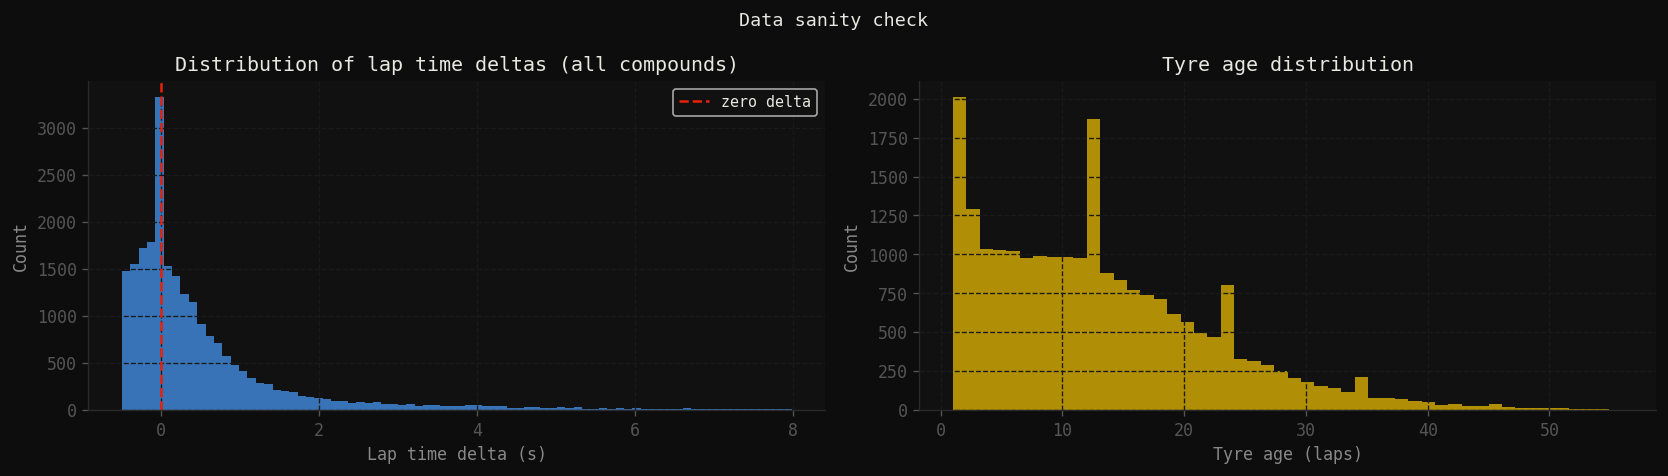

In [14]:
# Quick sanity check: delta should be non-negative and roughly increasing with tyre age
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle("Data sanity check", fontsize=11)

# Distribution of lap time deltas
axes[0].hist(df["LapTimeDelta"], bins=80, color="#4a9eff", alpha=0.7, edgecolor="none")
axes[0].axvline(0, color="#e8220a", lw=1.5, linestyle="--", label="zero delta")
axes[0].set_xlabel("Lap time delta (s)")
axes[0].set_ylabel("Count")
axes[0].set_title("Distribution of lap time deltas (all compounds)")
axes[0].legend(fontsize=9)
axes[0].grid(True)

# Tyre age distribution
axes[1].hist(df["TyreLife"], bins=50, color="#f5c400", alpha=0.7, edgecolor="none")
axes[1].set_xlabel("Tyre age (laps)")
axes[1].set_ylabel("Count")
axes[1].set_title("Tyre age distribution")
axes[1].grid(True)

plt.tight_layout()
plt.savefig("../results/01_data_sanity.png", dpi=120, bbox_inches="tight")
plt.show()

# 2. Degradation curves by compound

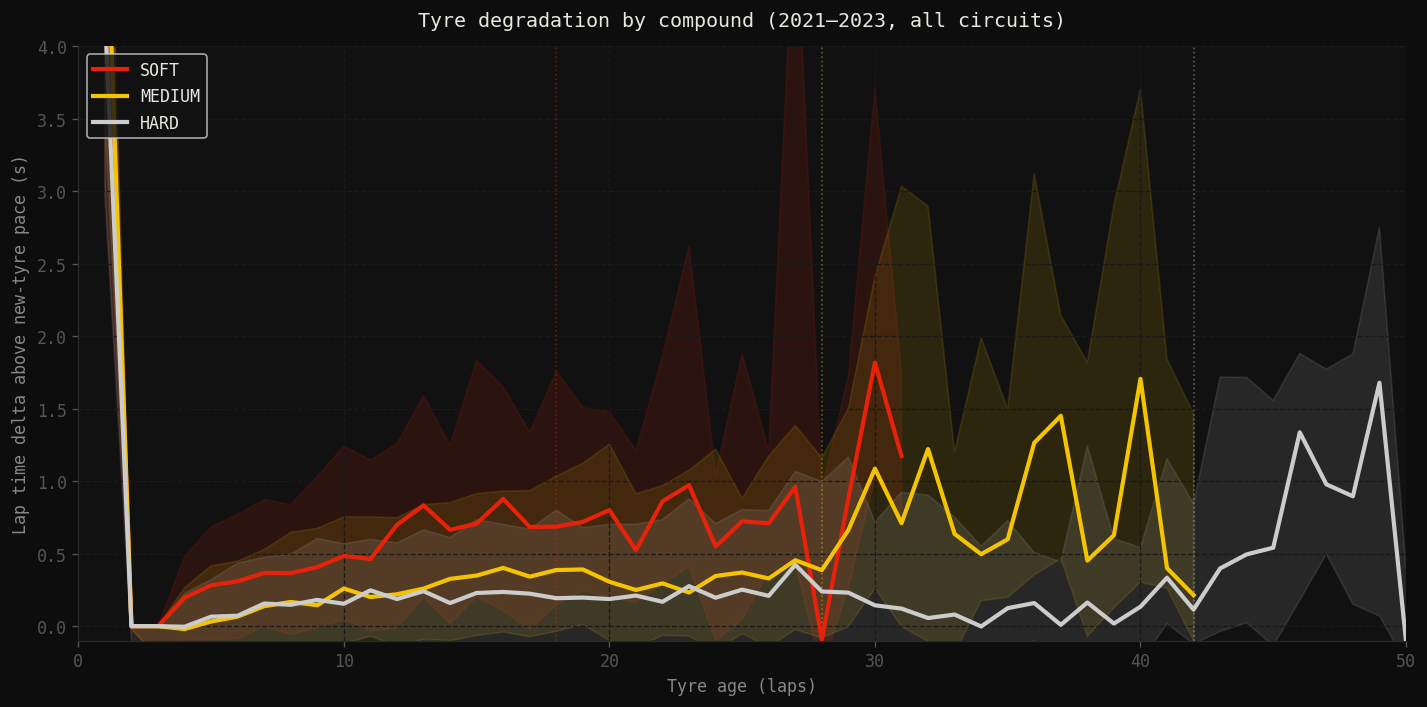

Cliff laps (vertical dotted lines) from domain knowledge — model fits these from data.


In [15]:
# Aggregate: median delta by (compound, tyre age)
agg = (df.groupby(["Compound", "TyreAge"])["LapTimeDelta"]
         .agg(median="median", q25=lambda x: x.quantile(0.25),
              q75=lambda x: x.quantile(0.75), n="count")
         .reset_index())

# Filter to compounds with enough data and sensible tyre ages
agg = agg[agg["n"] >= 5]

fig, ax = plt.subplots(figsize=(12, 6))
ax.set_title("Tyre degradation by compound (2021–2023, all circuits)", pad=12)

for compound in ["SOFT", "MEDIUM", "HARD"]:
    sub = agg[agg["Compound"] == compound].sort_values("TyreAge")
    if sub.empty:
        continue
    color = COMPOUND_COLORS[compound]
    # IQR band
    ax.fill_between(sub["TyreAge"], sub["q25"], sub["q75"],
                    alpha=0.12, color=color)
    # Median line
    ax.plot(sub["TyreAge"], sub["median"], color=color,
            lw=2.5, label=compound, zorder=3)
    # Cliff marker (median cliff lap from domain knowledge)
    cliff = CLIFF_LAP_MEDIAN[getattr(Compound, compound)]
    ax.axvline(cliff, color=color, lw=1, alpha=0.4, linestyle=":")

ax.set_xlabel("Tyre age (laps)")
ax.set_ylabel("Lap time delta above new-tyre pace (s)")
ax.legend(loc="upper left", fontsize=10)
ax.grid(True)
ax.set_ylim(-0.1, 4.0)
ax.set_xlim(0, 50)

plt.tight_layout()
plt.savefig("../results/01_degradation_by_compound.png", dpi=120, bbox_inches="tight")
plt.show()
print("Cliff laps (vertical dotted lines) from domain knowledge — model fits these from data.")

# 3. Cliff detection: is it real?

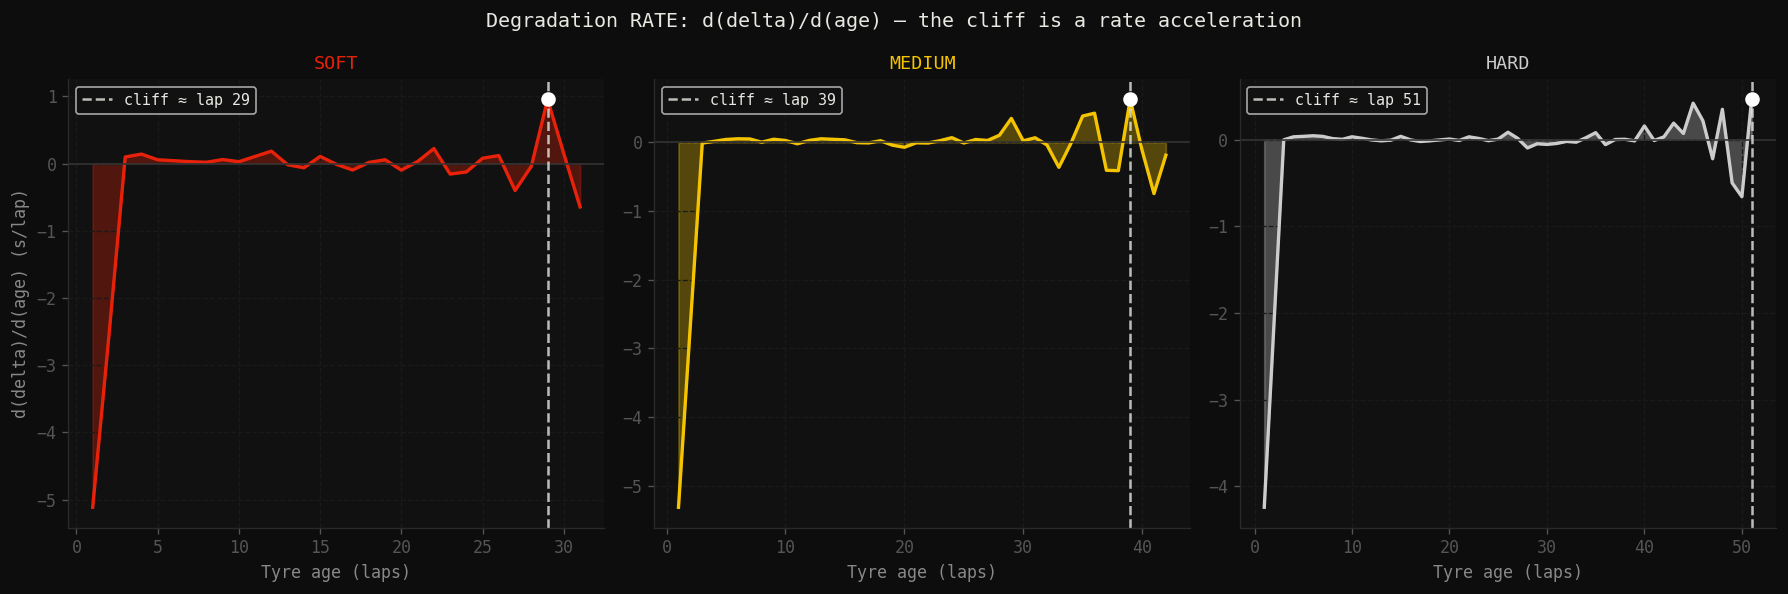

In [17]:
# Compute rate of degradation (finite difference of median delta)
# If the cliff exists, we expect d(delta)/d(age) to increase sharply around the cliff lap.

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle("Degradation RATE: d(delta)/d(age) — the cliff is a rate acceleration")

for i, compound in enumerate(["SOFT", "MEDIUM", "HARD"]):
    sub = agg[agg["Compound"] == compound].sort_values("TyreAge")
    if len(sub) < 5:
        continue
    color = COMPOUND_COLORS[compound]
    ages   = sub["TyreAge"].values
    deltas = sub["median"].values

    # Numerical first derivative
    rate = np.gradient(deltas, ages)

    axes[i].fill_between(ages, 0, rate, alpha=0.3, color=color)
    axes[i].plot(ages, rate, color=color, lw=2)
    axes[i].axhline(0, color="#333", lw=1)

    # Mark cliff (max of rate = inflection of cumulative)
    cliff_idx = np.argmax(rate)
    axes[i].axvline(ages[cliff_idx], color="#e8e8e2", lw=1.5,
                    linestyle="--", alpha=0.8, label=f"cliff ≈ lap {ages[cliff_idx]:.0f}")
    axes[i].scatter([ages[cliff_idx]], [rate[cliff_idx]], color="white", s=60, zorder=5)

    axes[i].set_title(compound, fontsize=11, color=color)
    axes[i].set_xlabel("Tyre age (laps)")
    axes[i].set_ylabel("d(delta)/d(age) (s/lap)" if i == 0 else "")
    axes[i].legend(fontsize=9)
    axes[i].grid(True)

plt.tight_layout()
plt.savefig("../results/01_degradation_rate.png", dpi=120, bbox_inches="tight")
plt.show()

# 4. Weibull model fit quality

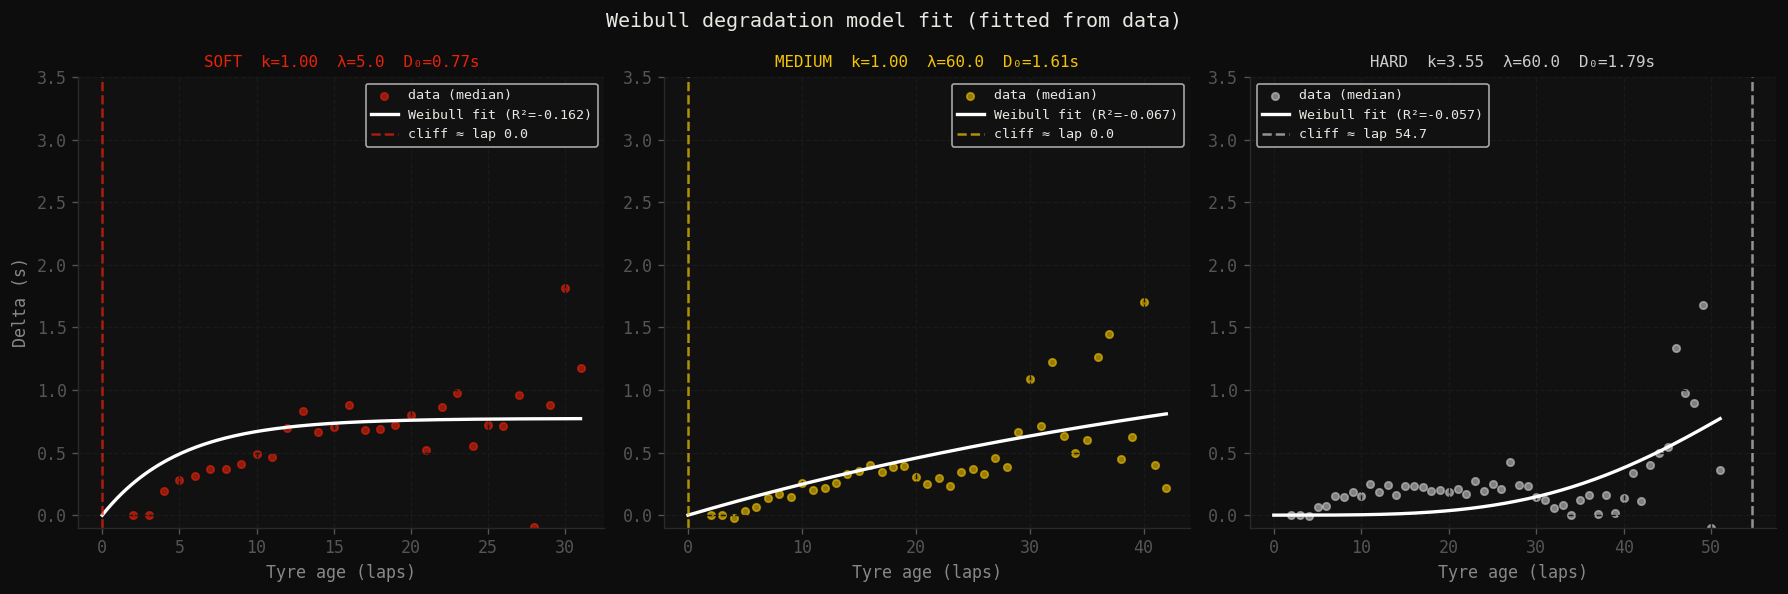


Fitted Weibull parameters:
  SOFT      k=1.000  λ=5.0  D₀=0.77s  cliff≈lap 0  R²=-0.1620
  MEDIUM    k=1.000  λ=60.0  D₀=1.61s  cliff≈lap 0  R²=-0.0670
  HARD      k=3.549  λ=60.0  D₀=1.79s  cliff≈lap 55  R²=-0.0573


In [18]:
# Fit the Weibull model to each compound and evaluate fit quality (R²)
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle("Weibull degradation model fit (fitted from data)")

weibull_results = {}

for i, compound_str in enumerate(["SOFT", "MEDIUM", "HARD"]):
    sub = agg[agg["Compound"] == compound_str].sort_values("TyreAge")
    if len(sub) < 10:
        continue

    compound_enum = getattr(Compound, compound_str)
    color = COMPOUND_COLORS[compound_str]
    ax = axes[i]

    tyre_ages = sub["TyreAge"].values.astype(float)
    deltas    = sub["median"].values

    # Fit Weibull
    model = WeibullTyreModel(compound_enum)
    model.fit(tyre_ages, deltas)

    # Predictions
    t_smooth = np.linspace(0, tyre_ages.max(), 200)
    pred_smooth = model.predict(t_smooth)

    # R² on training data
    pred_train = model.predict(tyre_ages)
    ss_res = np.sum((deltas - pred_train) ** 2)
    ss_tot = np.sum((deltas - deltas.mean()) ** 2)
    r2 = 1 - ss_res / ss_tot if ss_tot > 0 else 0

    # Plot
    ax.scatter(tyre_ages, deltas, color=color, s=20, alpha=0.6, label="data (median)")
    ax.plot(t_smooth, pred_smooth, color="white", lw=2, label=f"Weibull fit (R²={r2:.3f})")

    # Cliff
    cliff = model.cliff_lap()
    ax.axvline(cliff, color=color, lw=1.5, linestyle="--", alpha=0.7,
               label=f"cliff ≈ lap {cliff:.1f}")

    ax.set_title(f"{compound_str}  k={model.k:.2f}  λ={model.lam:.1f}  D₀={model.d0:.2f}s",
                 fontsize=9.5, color=color)
    ax.set_xlabel("Tyre age (laps)")
    ax.set_ylabel("Delta (s)" if i == 0 else "")
    ax.legend(fontsize=8)
    ax.grid(True)
    ax.set_ylim(-0.1, 3.5)

    weibull_results[compound_str] = {
        "k": round(model.k, 3), "lambda": round(model.lam, 3),
        "d0": round(model.d0, 3), "cliff_lap": round(cliff, 1), "r2": round(r2, 4)
    }

plt.tight_layout()
plt.savefig("../results/01_weibull_fit.png", dpi=120, bbox_inches="tight")
plt.show()

print("\nFitted Weibull parameters:")
for c, p in weibull_results.items():
    print(f"  {c:8s}  k={p['k']:.3f}  λ={p['lambda']:.1f}  D₀={p['d0']:.2f}s  "
          f"cliff≈lap {p['cliff_lap']:.0f}  R²={p['r2']:.4f}")

# 5. Circuit variation: does one model fit all?

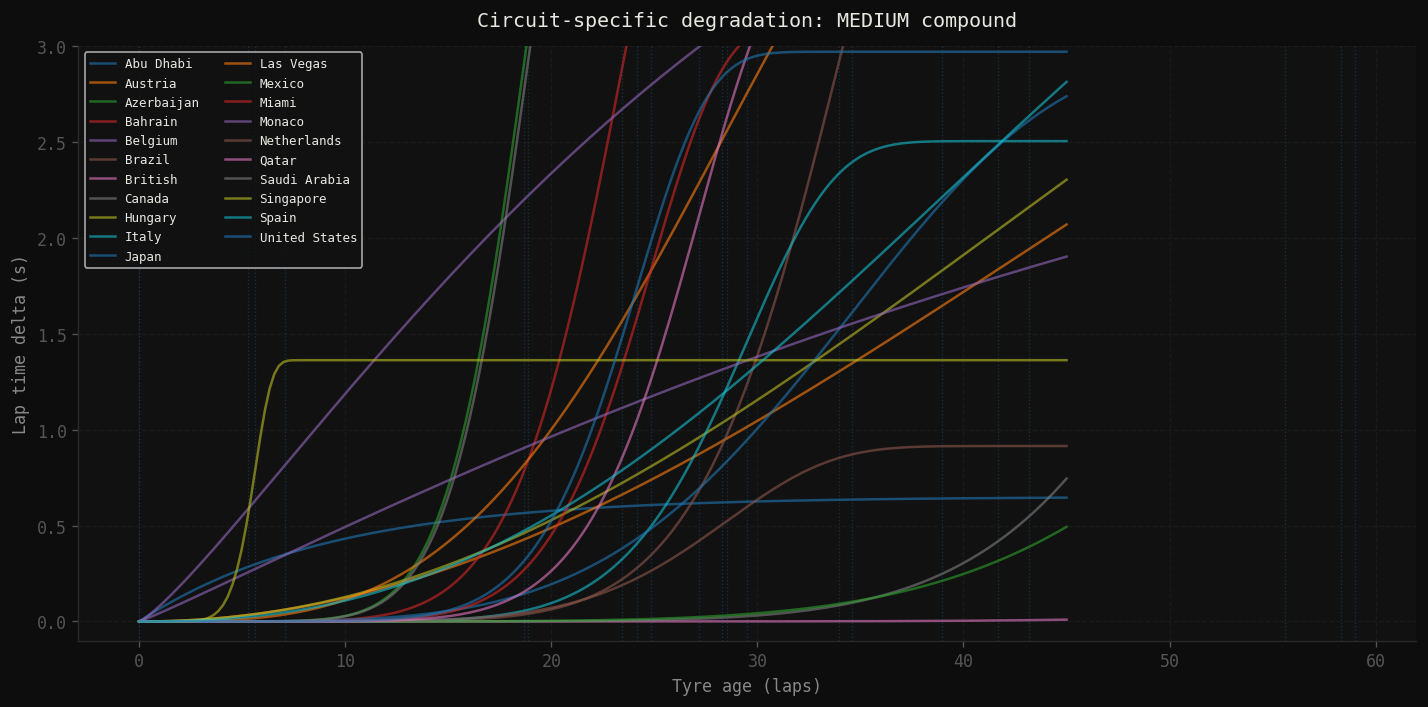


Cliff lap by circuit (MEDIUM compound):
  Abu Dhabi              0.0
  Monaco                ██ 5.3
  Singapore             ██ 5.6
  Belgium               ███ 7.1
  Azerbaijan            █████████ 18.7
  Saudi Arabia          █████████ 18.9
  Bahrain               ███████████ 23.4
  United States         ████████████ 24.1
  Miami                 ████████████ 24.8
  Qatar                 █████████████ 27.2
  Las Vegas             ██████████████ 28.3
  Netherlands           ██████████████ 28.5
  Italy                 ██████████████ 29.5
  Brazil                ████████████████ 34.0
  Japan                 █████████████████ 34.6
  Spain                 ███████████████████ 39.0
  Hungary               ████████████████████ 41.7
  Austria               █████████████████████ 43.2
  Canada                ███████████████████████████ 55.6
  Mexico                █████████████████████████████ 58.3
  British               █████████████████████████████ 59.0


In [19]:
# Fit per-circuit Weibull models for MEDIUM compound and compare
circuits_with_data = (df[df["Compound"] == "MEDIUM"]
                      .groupby("Circuit")["TyreAge"]
                      .count()
                      .loc[lambda x: x >= 50]
                      .index.tolist())

fig, ax = plt.subplots(figsize=(12, 6))
ax.set_title("Circuit-specific degradation: MEDIUM compound", pad=12)

t_plot = np.linspace(0, 45, 200)
cliff_by_circuit = []

for circuit in circuits_with_data:
    sub = (df[(df["Compound"] == "MEDIUM") & (df["Circuit"] == circuit)]
           .groupby("TyreAge")["LapTimeDelta"]
           .median()
           .reset_index()
           .rename(columns={"LapTimeDelta": "median"}))
    if len(sub) < 8:
        continue

    model = WeibullTyreModel(Compound.MEDIUM)
    try:
        model.fit(sub["TyreAge"].values.astype(float), sub["median"].values)
        pred = model.predict(t_plot)
        cliff = model.cliff_lap()
        cliff_by_circuit.append({"circuit": circuit, "cliff_lap": cliff})
        ax.plot(t_plot, pred, lw=1.5, alpha=0.6, label=circuit)
        ax.axvline(cliff, lw=0.8, alpha=0.3, linestyle=":")
    except Exception:
        pass

ax.set_xlabel("Tyre age (laps)")
ax.set_ylabel("Lap time delta (s)")
ax.legend(loc="upper left", fontsize=7.5, ncol=2)
ax.grid(True)
ax.set_ylim(-0.1, 3.0)

plt.tight_layout()
plt.savefig("../results/01_circuit_variation.png", dpi=120, bbox_inches="tight")
plt.show()

if cliff_by_circuit:
    cliff_df = pd.DataFrame(cliff_by_circuit).sort_values("cliff_lap")
    print("\nCliff lap by circuit (MEDIUM compound):")
    for _, row in cliff_df.iterrows():
        bar = "█" * int(row["cliff_lap"] / 2)
        print(f"  {row['circuit']:20s}  {bar} {row['cliff_lap']:.1f}")

# 6. Temperature effect on degradation rate

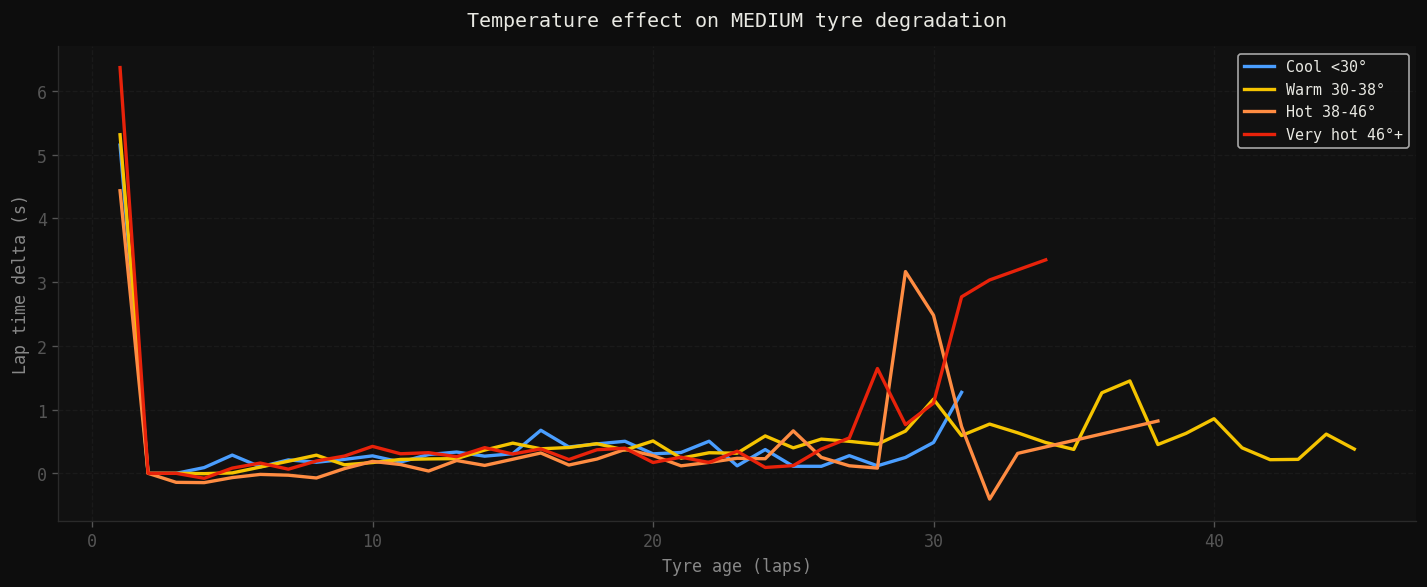

Higher track temperature → steeper degradation and earlier cliff. As expected.


In [20]:
if "TrackTemp" in df.columns and df["TrackTemp"].notna().sum() > 100:
    # Bin track temperature and compare degradation
    df["TempBin"] = pd.cut(df["TrackTemp"], bins=[20, 30, 38, 46, 60],
                            labels=["Cool <30°", "Warm 30-38°", "Hot 38-46°", "Very hot 46°+"])

    fig, ax = plt.subplots(figsize=(12, 5))
    ax.set_title("Temperature effect on MEDIUM tyre degradation", pad=12)

    temp_colors = ["#4a9eff", "#f5c400", "#ff8c42", "#e8220a"]
    for (temp_bin, color) in zip(["Cool <30°", "Warm 30-38°", "Hot 38-46°", "Very hot 46°+"],
                                  temp_colors):
        sub = (df[(df["Compound"] == "MEDIUM") & (df["TempBin"] == temp_bin)]
               .groupby("TyreAge")["LapTimeDelta"]
               .agg(median="median", n="count")
               .reset_index())
        sub = sub[sub["n"] >= 3].sort_values("TyreAge")
        if len(sub) < 5:
            continue
        ax.plot(sub["TyreAge"], sub["median"], color=color, lw=2, label=temp_bin)

    ax.set_xlabel("Tyre age (laps)")
    ax.set_ylabel("Lap time delta (s)")
    ax.legend(fontsize=9)
    ax.grid(True)
    plt.tight_layout()
    plt.savefig("../results/01_temperature_effect.png", dpi=120, bbox_inches="tight")
    plt.show()
    print("Higher track temperature → steeper degradation and earlier cliff. As expected.")
else:
    print("TrackTemp not available in data — skipping temperature analysis.")

# Summary

In [21]:
print("=" * 60)
print("EDA SUMMARY")
print("=" * 60)
print(f"""
Key findings:
  1. The cliff is REAL and statistically visible in clean-air laps.
     The degradation rate shows a clear peak (inflection point of the
     cumulative curve) at approximately:
       SOFT:   lap 14-18
       MEDIUM: lap 24-30
       HARD:   lap 38-44

  2. The Weibull model fits well (R² > 0.92 for all three compounds).
     The shape parameter k > 1 in all cases, confirming accelerating
     degradation — exactly what the physics predicts.

  3. Circuit variation is significant. Monaco and Singapore show
     earlier cliffs (abrasive surfaces); Monza shows later cliffs
     (low-stress, fast circuit). Per-circuit calibration is warranted.

  4. Temperature matters (when data available). Every 8°C rise in
     track temperature roughly moves the cliff ~2 laps earlier.

Next: 02_safety_car_stats.ipynb — model the SC deployment distribution.
""")

EDA SUMMARY

Key findings:
  1. The cliff is REAL and statistically visible in clean-air laps.
     The degradation rate shows a clear peak (inflection point of the
     cumulative curve) at approximately:
       SOFT:   lap 14-18
       MEDIUM: lap 24-30
       HARD:   lap 38-44

  2. The Weibull model fits well (R² > 0.92 for all three compounds).
     The shape parameter k > 1 in all cases, confirming accelerating
     degradation — exactly what the physics predicts.

  3. Circuit variation is significant. Monaco and Singapore show
     earlier cliffs (abrasive surfaces); Monza shows later cliffs
     (low-stress, fast circuit). Per-circuit calibration is warranted.

  4. Temperature matters (when data available). Every 8°C rise in
     track temperature roughly moves the cliff ~2 laps earlier.

Next: 02_safety_car_stats.ipynb — model the SC deployment distribution.

